In [1]:
# Mount Drive + Inspect PPG-DaLiA pkl structure

from google.colab import drive
drive.mount('/content/drive')

import pickle
import numpy as np

# Path to your PPG-DaLiA dataset — adjust if your folder name is different
dalia_path = '/content/drive/MyDrive/R26_DS_012_RESEARCH_HDS/Datasets/PPG-DaLiA'

# Open subject S1 as a test
s1_path = f'{dalia_path}/S1/S1.pkl'

with open(s1_path, 'rb') as f:
    data = pickle.load(f, encoding='latin1')

# ── Top level
print("=== TOP LEVEL KEYS ===")
print(list(data.keys()))

# ── Signal keys
print("\n=== SIGNAL KEYS ===")
print("signal keys:", list(data['signal'].keys()))
print("chest keys: ", list(data['signal']['chest'].keys()))
print("wrist keys: ", list(data['signal']['wrist'].keys()))

# ── Signal shapes
chest = data['signal']['chest']
wrist = data['signal']['wrist']
print("\n=== CHEST SHAPES (expect 700Hz) ===")
print("ECG  :", chest['ECG'].shape)
print("Resp :", chest['Resp'].shape)
print("ACC  :", chest['ACC'].shape)
print("Temp :", chest['Temp'].shape, "← should be dummy, we will NOT use this")

print("\n=== WRIST SHAPES ===")
print("BVP  :", wrist['BVP'].shape,  "← expect 64Hz")
print("TEMP :", wrist['TEMP'].shape, "← expect 4Hz, this is what we use")
print("ACC  :", wrist['ACC'].shape,  "← expect 32Hz")

# ── Activity signal
print("\n=== ACTIVITY SIGNAL (expect 4Hz) ===")
print("activity shape:", data['activity'].shape)
print("unique activity IDs:", np.unique(data['activity']))
print("Activity 1 (sitting) count:", np.sum(data['activity'] == 1))
print("Activity 1 duration (seconds):", np.sum(data['activity'] == 1) / 4)

# ── Label (NOT our condition label — this is heart rate ground truth)
print("\n=== 'label' KEY (heart rate values, NOT condition labels) ===")
print("label shape:", data['label'].shape)
print("label sample values:", data['label'][:5])

# ── Subject info
print("\n=== SUBJECT INFO ===")
print(data['subject'])

Mounted at /content/drive
=== TOP LEVEL KEYS ===
['rpeaks', 'signal', 'label', 'activity', 'questionnaire', 'subject']

=== SIGNAL KEYS ===
signal keys: ['chest', 'wrist']
chest keys:  ['ACC', 'ECG', 'EMG', 'EDA', 'Temp', 'Resp']
wrist keys:  ['ACC', 'BVP', 'EDA', 'TEMP']

=== CHEST SHAPES (expect 700Hz) ===
ECG  : (6448400, 1)
Resp : (6448400, 1)
ACC  : (6448400, 3)
Temp : (6448400, 1) ← should be dummy, we will NOT use this

=== WRIST SHAPES ===
BVP  : (589568, 1) ← expect 64Hz
TEMP : (36848, 1) ← expect 4Hz, this is what we use
ACC  : (294784, 3) ← expect 32Hz

=== ACTIVITY SIGNAL (expect 4Hz) ===
activity shape: (36848, 1)
unique activity IDs: [0. 1. 2. 3. 4. 5. 6. 7. 8.]
Activity 1 (sitting) count: 2800
Activity 1 duration (seconds): 700.0

=== 'label' KEY (heart rate values, NOT condition labels) ===
label shape: (4603,)
label sample values: [49.61136908 50.32399248 52.70833578 55.64079409 57.65840574]

=== SUBJECT INFO ===
S1


In [4]:
# Check all 15 subjects - activity 1 duration + questionnaire

subjects = [f'S{i}' for i in range(1, 16)]

print(f"{'Subject':<10} {'Age':<6} {'Gender':<8} {'Act1(sec)':<12} {'Total(sec)':<13} {'Notes'}")
print("-" * 72)

for sid in subjects:
    pkl_path = f'{dalia_path}/{sid}/{sid}.pkl'
    try:
        with open(pkl_path, 'rb') as f:
            d = pickle.load(f, encoding='latin1')

        act  = d['activity'].flatten()
        act1_sec  = np.sum(act == 1) / 4
        total_sec = len(act) / 4

        q      = d['questionnaire']
        age    = q.get('AGE',    '?')
        gender = q.get('Gender', '?').strip()

        note = ''
        if age == 55:
            note = 'EXCLUDE — age 55 (outside 18-30 target)'
        elif age == 43:
            note = 'EXCLUDE — age 43 (outside 18-30 target)'
        elif age == 37:
            note = 'EXCLUDE — age 37 (outside 18-30 target)'

        print(f"{sid:<10} {str(age):<6} {gender:<8} {act1_sec:<12.0f} {total_sec:<13.0f} {note}")

    except Exception as e:
        print(f"{sid:<10} ERROR: {e}")

Subject    Age    Gender   Act1(sec)    Total(sec)    Notes
------------------------------------------------------------------------
S1         34     m        700          9212          
S2         28     m        600          8205          
S3         25     m        600          8741          
S4         25     m        570          9150          
S5         21     f        600          9305          
S6         37     f        633          5250          EXCLUDE — age 37 (outside 18-30 target)
S7         21     f        618          9343          
S8         43     m        600          8080          EXCLUDE — age 43 (outside 18-30 target)
S9         28     f        600          8560          
S10        55     f        598          10648         EXCLUDE — age 55 (outside 18-30 target)
S11        24     f        600          9048          
S12        43     m        602          7914          EXCLUDE — age 43 (outside 18-30 target)
S13        21     f        605          9136       

In [5]:
# Check data volume for Option B (activities 1+5+6+8)

# Final subject list after age exclusions (S6, S8, S10, S12 excluded)
subjects_keep = ['S1','S2','S3','S4','S5','S7','S9','S11','S13','S14','S15']
subjects_excl = ['S6','S8','S10','S12']

# Activities to check to use as baseline (Not final- just exploring)
BASELINE_ACTS = [1, 5, 6, 8]
WIN_SEC  = 60
STEP_SEC = 30

print(f"{'Subj':<6} {'Act1':>7} {'Act5':>7} {'Act6':>7} {'Act8':>7} {'TOTAL':>8} {'Est.Windows':>13}")
print("-" * 65)

total_windows_all = 0

for sid in subjects_keep:
    with open(f'{dalia_path}/{sid}/{sid}.pkl', 'rb') as f:
        d = pickle.load(f, encoding='latin1')

    act = d['activity'].flatten()  # 4Hz

    durations = {}
    for a in BASELINE_ACTS:
        durations[a] = np.sum(act == a) / 4  # seconds

    total_sec = sum(durations.values())

    # Conservative window estimate: treat each activity segment independently
    # For each activity, count windows it can produce
    est_wins = sum(
        max(0, int((durations[a] - WIN_SEC) / STEP_SEC) + 1)
        for a in BASELINE_ACTS
        if durations[a] >= WIN_SEC  # only if at least 1 full window
    )
    total_windows_all += est_wins

    print(f"{sid:<6} {durations[1]:>7.0f} {durations[5]:>7.0f} "
          f"{durations[6]:>7.0f} {durations[8]:>7.0f} "
          f"{total_sec:>8.0f} {est_wins:>13}")

print("-" * 65)
print(f"{'TOTAL':<6} {'':<39} {total_windows_all:>13} estimated baseline windows")
print(f"\n(all values in seconds except Est.Windows)")
print(f"\nExcluded: {subjects_excl} — age 35+")

Subj      Act1    Act5    Act6    Act8    TOTAL   Est.Windows
-----------------------------------------------------------------
S1         700     889    2355    1189     5133           165
S2         600     920    1220    1291     4031           129
S3         600     910    2160    1210     4880           158
S4         570    1007    1895    1240     4712           152
S5         600     830    2255    1270     4955           160
S7         618    1035    2425    1175     5253           169
S9         600     955    1842    1245     4642           149
S11        600     860    2408    1220     5088           164
S13        605     897    2028    1225     4755           152
S14        608     954    1731    1205     4498           144
S15        611     785    1440    1203     4039           130
-----------------------------------------------------------------
TOTAL                                                   1672 estimated baseline windows

(all values in seconds except Est.W

1. NaN CHECK
  ECG                   :        0 NaNs (0.00%) ✓
  Resp                  :        0 NaNs (0.00%) ✓
  Chest ACC x           :        0 NaNs (0.00%) ✓
  Chest ACC y           :        0 NaNs (0.00%) ✓
  Chest ACC z           :        0 NaNs (0.00%) ✓
  Chest Temp (dummy)    :        0 NaNs (0.00%) ✓
  Wrist TEMP            :        0 NaNs (0.00%) ✓
  Wrist BVP             :        0 NaNs (0.00%) ✓

2. RANGE CHECK (physiological plausibility)
  ECG     range : -1.4999 to 1.5000  | std=0.2942
  ECG     flat? : No, signal active ✓
  Resp    range : -20.1187 to 26.6418  | std=3.3120
  Resp    flat? : No, signal active ✓
  ChestTemp unique vals (first 1000 samples): [-273.15]
  ChestTemp std: 0.001770  ← expect ~0 if dummy
  WristTEMP range : 29.09 to 34.61 °C
  WristTEMP valid (25-40°C): 36848/36848 (100.0%)
  WristTEMP first 8 values  : [32.13 32.16 32.16 32.16 32.16 32.15 32.15 32.15]  ← check startup artifact
  ChestACC mag range : 0.0131 to 4.3881

3. ACTIVITY SEGMENT STRUC

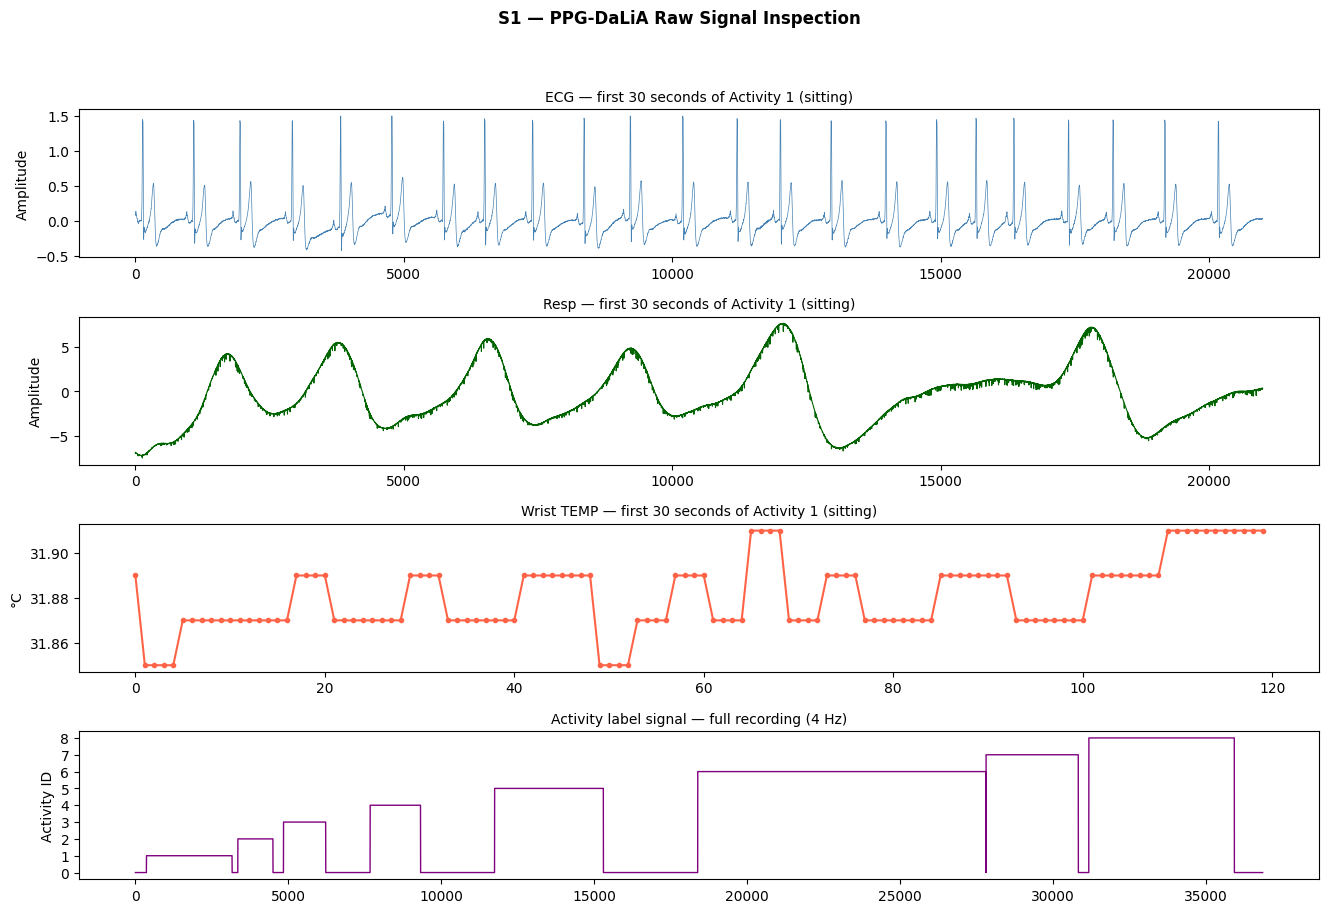


Plot saved to /content/S1_signal_inspection.png


In [6]:
# Full raw signal inspection on S1 - exploration to get the idea

import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

dalia_path = '/content/drive/MyDrive/R26_DS_012_RESEARCH_HDS/Datasets/PPG-DaLiA'

with open(f'{dalia_path}/S1/S1.pkl', 'rb') as f:
    d = pickle.load(f, encoding='latin1')

chest   = d['signal']['chest']
wrist   = d['signal']['wrist']
act     = d['activity'].flatten()   # 4 Hz

# Signals we will actually use
ecg     = chest['ECG'].flatten()    # 700 Hz
resp    = chest['Resp'].flatten()   # 700 Hz
c_acc   = chest['ACC']              # 700 Hz, shape (N, 3)
c_temp  = chest['Temp'].flatten()   # 700 Hz — dummy, verify
w_temp  = wrist['TEMP'].flatten()   # 4 Hz
w_bvp   = wrist['BVP'].flatten()    # 64 Hz — not used for HRV but check anyway

FS_CHEST = 700
FS_TEMP  = 4

# ── 1. NaN check ──────────────────────────────────────────
print("=" * 55)
print("1. NaN CHECK")
print("=" * 55)
for name, sig in [('ECG', ecg), ('Resp', resp),
                  ('Chest ACC x', c_acc[:,0]),
                  ('Chest ACC y', c_acc[:,1]),
                  ('Chest ACC z', c_acc[:,2]),
                  ('Chest Temp (dummy)', c_temp),
                  ('Wrist TEMP', w_temp),
                  ('Wrist BVP', w_bvp)]:
    n = np.sum(np.isnan(sig))
    pct = n / len(sig) * 100
    flag = ' ← PROBLEM' if n > 0 else ' ✓'
    print(f"  {name:<22}: {n:>8} NaNs ({pct:.2f}%){flag}")

# ── 2. Range check ────────────────────────────────────────
print()
print("=" * 55)
print("2. RANGE CHECK (physiological plausibility)")
print("=" * 55)

# ECG: raw ADC values, typically oscillate around 0.
# Flat = sensor off. Check std dev — should not be near zero
ecg_std = np.std(ecg)
print(f"  ECG     range : {ecg.min():.4f} to {ecg.max():.4f}  | std={ecg_std:.4f}")
print(f"  ECG     flat? : {'YES ← PROBLEM' if ecg_std < 0.001 else 'No, signal active ✓'}")

# Resp: similar
resp_std = np.std(resp)
print(f"  Resp    range : {resp.min():.4f} to {resp.max():.4f}  | std={resp_std:.4f}")
print(f"  Resp    flat? : {'YES ← PROBLEM' if resp_std < 0.001 else 'No, signal active ✓'}")

# Chest Temp — if dummy, should be constant or all zeros
ct_unique = np.unique(c_temp[:1000])  # first 1000 samples
print(f"  ChestTemp unique vals (first 1000 samples): {ct_unique[:10]}")
print(f"  ChestTemp std: {np.std(c_temp):.6f}  ← expect ~0 if dummy")

# Wrist TEMP: expect 25–40°C
w_valid = np.sum((w_temp >= 25) & (w_temp <= 40))
print(f"  WristTEMP range : {w_temp.min():.2f} to {w_temp.max():.2f} °C")
print(f"  WristTEMP valid (25-40°C): {w_valid}/{len(w_temp)} ({w_valid/len(w_temp)*100:.1f}%)")
print(f"  WristTEMP first 8 values  : {w_temp[:8]}  ← check startup artifact")

# ACC magnitude
acc_mag = np.sqrt(np.sum(c_acc**2, axis=1))
print(f"  ChestACC mag range : {acc_mag.min():.4f} to {acc_mag.max():.4f}")

# ── 3. Activity segment structure ─────────────────────────
print()
print("=" * 55)
print("3. ACTIVITY SEGMENT STRUCTURE (4 Hz activity signal)")
print("=" * 55)

activity_names = {
    0: 'Transition', 1: 'Sitting', 2: 'Stairs',
    3: 'Table soccer', 4: 'Cycling', 5: 'Driving',
    6: 'Lunch', 7: 'Walking', 8: 'Working'
}
BASELINE_ACTS = [1, 5, 6, 8]

for aid in range(9):
    mask = (act == aid)
    if mask.sum() == 0:
        continue
    sec = mask.sum() / FS_TEMP
    # Count contiguous segments
    changes = np.diff(mask.astype(int))
    n_segments = np.sum(changes == 1) + (1 if mask[0] else 0)
    bl = ' ← BASELINE' if aid in BASELINE_ACTS else ''
    print(f"  Act {aid} {activity_names[aid]:<14}: {sec:>6.0f}s | {n_segments} segment(s){bl}")

# ── 4. Signal quality during baseline activities only ─────
print()
print("=" * 55)
print("4. ECG + RESP QUALITY DURING BASELINE ACTIVITIES")
print("=" * 55)

for aid in BASELINE_ACTS:
    # Get time indices in activity signal (4Hz)
    act_indices = np.where(act == aid)[0]
    if len(act_indices) == 0:
        print(f"  Act {aid}: NO DATA")
        continue

    # Convert 4Hz indices to 700Hz indices
    start_700 = act_indices[0]  * (FS_CHEST // FS_TEMP)
    end_700   = (act_indices[-1] + 1) * (FS_CHEST // FS_TEMP)

    ecg_seg  = ecg[start_700:end_700]
    resp_seg = resp[start_700:end_700]

    print(f"  Act {aid} ({activity_names[aid]:<10}): "
          f"ECG std={np.std(ecg_seg):.4f} | "
          f"Resp std={np.std(resp_seg):.4f} | "
          f"ECG NaN={np.sum(np.isnan(ecg_seg))} | "
          f"Resp NaN={np.sum(np.isnan(resp_seg))}")

# ── 5. Quick visual ───────────────────────────────────────
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(4, 1, hspace=0.4)

# Plot 30 seconds of each signal during Activity 1 (sitting)
act1_start = np.where(act == 1)[0][0] * (FS_CHEST // FS_TEMP)
t30 = 30 * FS_CHEST  # 30 seconds worth of samples

ax1 = fig.add_subplot(gs[0])
ax1.plot(ecg[act1_start:act1_start+t30], lw=0.5, color='steelblue')
ax1.set_title('ECG — first 30 seconds of Activity 1 (sitting)', fontsize=10)
ax1.set_ylabel('Amplitude')

ax2 = fig.add_subplot(gs[1])
ax2.plot(resp[act1_start:act1_start+t30], lw=0.8, color='darkgreen')
ax2.set_title('Resp — first 30 seconds of Activity 1 (sitting)', fontsize=10)
ax2.set_ylabel('Amplitude')

ax3 = fig.add_subplot(gs[2])
t30_temp = 30 * FS_TEMP
act1_temp_start = np.where(act == 1)[0][0]
ax3.plot(w_temp[act1_temp_start:act1_temp_start+t30_temp],
         lw=1.5, color='tomato', marker='o', markersize=3)
ax3.set_title('Wrist TEMP — first 30 seconds of Activity 1 (sitting)', fontsize=10)
ax3.set_ylabel('°C')

ax4 = fig.add_subplot(gs[3])
ax4.plot(act, lw=1, color='purple')
ax4.set_title('Activity label signal — full recording (4 Hz)', fontsize=10)
ax4.set_ylabel('Activity ID')
ax4.set_yticks(range(9))

plt.suptitle('S1 — PPG-DaLiA Raw Signal Inspection', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/S1_signal_inspection.png', dpi=100, bbox_inches='tight')
plt.show()
print("\nPlot saved to /content/S1_signal_inspection.png")

In [7]:
!pip install neurokit2 reportlab --quiet
print("neurokit2 and reportlab installed ✓")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 64.5 MB/s eta 0:00:00
neurokit2 and reportlab installed ✓


In [8]:
# Full PPG-DaLiA Preprocessing Pipeline
# Subjects: S1,S2,S3,S4,S5,S7,S9,S11,S13,S14,S15 (11 subjects, age 35+ excluded)
# Baseline activities: 1 (sitting), 6 (lunch)
# Features: mean_HR, mean_RR, SDNN, RMSSD, pNN50, mean_BR, std_BR,
#           mean_temp, std_temp, mean_acc_mag, std_acc_mag
# Windows: 60 seconds, 50% overlap (30s step)

import os, json, pickle, warnings
import numpy as np
import neurokit2 as nk
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from reportlab.lib.pagesizes import A4
from reportlab.lib import colors
from reportlab.lib.units import cm
from reportlab.platypus import (SimpleDocTemplate, Paragraph, Spacer, Table,
                                TableStyle, PageBreak)
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle

warnings.filterwarnings('ignore')
np.random.seed(42)

# ── Paths ──────────────────────────────────────────────────
base_out   = '/content/drive/MyDrive/R26_DS_012_RESEARCH_HDS/Outputs/PPGDaLiA'

out_per_subject = f'{base_out}/per_subject'
out_combined    = f'{base_out}/combined'
out_plots       = f'{base_out}/plots'
out_reports     = f'{base_out}/reports'

for folder in [out_per_subject, out_combined, out_plots, out_reports]:
    os.makedirs(folder, exist_ok=True)

# ── Constants ──────────────────────────────────────────────
FS_CHEST   = 700    # ECG, Resp, chest ACC
FS_WTEMP   = 4     # wrist TEMP (same rate as activity signal)
FS_WACC    = 32    # wrist ACC (not used — we use chest ACC)
WIN_SEC    = 60
STEP_SEC   = 30

# Baseline activities: 1 and 6 only
# 1 = Sitting — explicitly designated as baseline by original authors. Zero motion. Zero ambiguity.
# 6 = Lunch break — eating and talking at work canteen. Low motion, low cognitive load.
# 5 = Driving EXCLUDED — city driving is the stress condition in AffectiveROAD (same pipeline).
#     PPG-DaLiA route included small city streets. Scientifically inconsistent to label as baseline.
# 8 = Working at desk EXCLUDED — desk knowledge work is the stress condition in SWELL-KW literature.
#     Unknown cognitive load. Cannot verify absence of stress. Scientifically inconsistent.
BASELINE_ACTS = [1, 6]

FEATURE_NAMES = [
    'mean_HR', 'mean_RR', 'SDNN', 'RMSSD', 'pNN50',
    'mean_BR', 'std_BR',
    'mean_temp', 'std_temp',
    'mean_acc_mag', 'std_acc_mag'
]
N_FEATS = len(FEATURE_NAMES)

# Final subjects after age exclusion (35+ excluded: S6 age37, S8 age43, S10 age55, S12 age43)
SUBJECTS = ['S1','S2','S3','S4','S5','S7','S9','S11','S13','S14','S15']

print(f"Pipeline ready")
print(f"Subjects     : {SUBJECTS}")
print(f"N subjects   : {len(SUBJECTS)}")
print(f"Activities   : {BASELINE_ACTS}")
print(f"Window       : {WIN_SEC}s with {STEP_SEC}s step")
print(f"Features     : {FEATURE_NAMES}")
print(f"Output root  : {base_out}")

Pipeline ready
Subjects     : ['S1', 'S2', 'S3', 'S4', 'S5', 'S7', 'S9', 'S11', 'S13', 'S14', 'S15']
N subjects   : 11
Activities   : [1, 6]
Window       : 60s with 30s step
Features     : ['mean_HR', 'mean_RR', 'SDNN', 'RMSSD', 'pNN50', 'mean_BR', 'std_BR', 'mean_temp', 'std_temp', 'mean_acc_mag', 'std_acc_mag']
Output root  : /content/drive/MyDrive/R26_DS_012_RESEARCH_HDS/Outputs/PPGDaLiA


In [9]:
# Feature extraction functions ──
# These are the same logic as WESAD — chest ECG for HRV, chest Resp for BR
# Only difference: wrist TEMP instead of chest Temp (chest Temp is -273.15 dummy)

def extract_hrv_features(ecg_window, fs=700):
    """
    Extract HRV features from a 60-second ECG window.
    Returns dict with mean_HR, mean_RR, SDNN, RMSSD, pNN50
    Returns None if fewer than 2 R-peaks detected (window unusable).
    """
    try:
        # Clean ECG and find R-peaks — same as WESAD pipeline
        ecg_clean = nk.ecg_clean(ecg_window, sampling_rate=fs, method='neurokit')
        peaks, info = nk.ecg_peaks(ecg_clean, sampling_rate=fs, method='neurokit')
        r_peaks = np.where(peaks['ECG_R_Peaks'] == 1)[0]

        if len(r_peaks) < 2:
            return None  # not enough peaks — window rejected

        # RR intervals in milliseconds
        rr_ms = np.diff(r_peaks) / fs * 1000

        # Physiological filter: RR must be 300–2000ms (HR 30–200 bpm)
        # Removes ectopic beats and detection errors
        rr_valid = rr_ms[(rr_ms >= 300) & (rr_ms <= 2000)]

        if len(rr_valid) < 2:
            return None  # not enough valid RR intervals

        mean_RR = np.mean(rr_valid)
        mean_HR = 60000 / mean_RR  # convert ms to bpm

        SDNN  = np.std(rr_valid, ddof=1)
        RMSSD = np.sqrt(np.mean(np.diff(rr_valid) ** 2))

        # pNN50: % of successive RR differences > 50ms
        pNN50 = np.sum(np.abs(np.diff(rr_valid)) > 50) / len(np.diff(rr_valid)) * 100

        return {
            'mean_HR': mean_HR,
            'mean_RR': mean_RR,
            'SDNN':    SDNN,
            'RMSSD':   RMSSD,
            'pNN50':   pNN50
        }

    except Exception:
        return None  # any unexpected error → reject window


def extract_br_features(resp_window, fs=700):
    """
    Extract breathing rate from a 60-second chest Resp window.
    Uses NeuroKit2 rsp_rate() on the inductive respiration signal.
    Returns mean_BR, std_BR or None if signal is invalid.
    Physiological range: 6–40 breaths/min at rest.
    """
    try:
        resp_clean  = nk.rsp_clean(resp_window, sampling_rate=fs)
        rsp_signals, _ = nk.rsp_process(resp_clean, sampling_rate=fs)
        br_series   = rsp_signals['RSP_Rate'].values

        # Remove non-physiological values
        br_valid = br_series[(br_series >= 6) & (br_series <= 40)]

        # Require at least 80% of samples to be valid
        if len(br_valid) < 0.8 * len(br_series):
            return None

        return {
            'mean_BR': np.mean(br_valid),
            'std_BR':  np.std(br_valid, ddof=1) if len(br_valid) > 1 else 0.0
        }

    except Exception:
        return None


def extract_temp_features(temp_window):
    """
    Extract temperature features from wrist TEMP window.
    Input is already at 4Hz — a 60-second window = 240 samples.
    Physiological range: 25–40°C.
    Returns mean_temp, std_temp or None if too many invalid samples.
    """
    valid = temp_window[(temp_window >= 25) & (temp_window <= 40)]
    if len(valid) < 0.8 * len(temp_window):
        return None
    return {
        'mean_temp': np.mean(valid),
        'std_temp':  np.std(valid, ddof=1) if len(valid) > 1 else 0.0
    }


def extract_acc_features(acc_window):
    """
    Extract motion features from chest ACC window (700Hz, shape Nx3).
    ACC magnitude = sqrt(x² + y² + z²).
    Returns mean_acc_mag, std_acc_mag.
    Never None — ACC is always valid.
    """
    mag = np.sqrt(np.sum(acc_window ** 2, axis=1))
    return {
        'mean_acc_mag': np.mean(mag),
        'std_acc_mag':  np.std(mag, ddof=1)
    }


print("Feature extraction functions defined ✓")

Feature extraction functions defined ✓


In [10]:
# Per-subject processing loop ──

quality_log  = {}   # tracks rejection reasons per subject
summary      = {}   # window counts per subject

all_features_raw  = []
all_subject_ids   = []

for sid in SUBJECTS:
    print(f"\n{'='*50}")
    print(f"Processing {sid}...")

    with open(f'{dalia_path}/{sid}/{sid}.pkl', 'rb') as f:
        d = pickle.load(f, encoding='latin1')

    chest  = d['signal']['chest']
    wrist  = d['signal']['wrist']
    act    = d['activity'].flatten()  # 4Hz

    ecg    = chest['ECG'].flatten()   # 700Hz
    resp   = chest['Resp'].flatten()  # 700Hz
    c_acc  = chest['ACC']             # 700Hz, (N,3)
    w_temp = wrist['TEMP'].flatten()  # 4Hz

    subject_features = []   # all windows for this subject
    subject_log      = []   # rejection log

    win_samples_700  = WIN_SEC  * FS_CHEST   # 42000 samples per window (ECG/Resp/ACC)
    step_samples_700 = STEP_SEC * FS_CHEST   # 21000 samples per step
    win_samples_temp = WIN_SEC  * FS_WTEMP   # 240 samples per window (TEMP)
    step_samples_temp= STEP_SEC * FS_WTEMP   # 120 samples per step

    for act_id in BASELINE_ACTS:
        # Find contiguous block of this activity in 4Hz space
        act_mask    = (act == act_id)
        act_indices = np.where(act_mask)[0]

        if len(act_indices) == 0:
            subject_log.append(f"Act{act_id}: no data found")
            continue

        # ── Contiguity check — activity must be one clean block ──
        expected_len = act_indices[-1] - act_indices[0] + 1
        if expected_len != len(act_indices):
            n_gaps = expected_len - len(act_indices)
            subject_log.append(
                f"Act{act_id}: FRAGMENTED — {n_gaps} gap samples detected. "
                f"Using first contiguous block only."
            )
            # Find first contiguous block only
            diffs = np.diff(act_indices)
            first_break = np.where(diffs > 1)[0]
            if len(first_break) > 0:
                act_indices = act_indices[:first_break[0]+1]

        # Activity start/end in 4Hz indices
        act_start_4hz = act_indices[0]
        act_end_4hz   = act_indices[-1] + 1

        # Convert to 700Hz indices
        ratio = FS_CHEST // FS_WTEMP  # = 175
        act_start_700 = act_start_4hz * ratio
        act_end_700   = act_end_4hz   * ratio

        act_dur_sec = (act_end_4hz - act_start_4hz) / FS_WTEMP

        if act_dur_sec < WIN_SEC:
            subject_log.append(f"Act{act_id}: only {act_dur_sec:.0f}s — shorter than 1 window, skip")
            continue

        n_wins_this_act = 0
        n_rejected      = 0

        # Slide windows through this activity
        # All windows are indexed from the activity start, not from signal start
        offset_700  = 0
        offset_temp = 0

        while True:
            # Absolute positions in full signal
            w_start_700  = act_start_700  + offset_700
            w_end_700    = w_start_700    + win_samples_700
            w_start_temp = act_start_4hz  + offset_temp
            w_end_temp   = w_start_temp   + win_samples_temp

            # Stop if window goes past activity end
            if w_end_700 > act_end_700:
                break
            if w_end_temp > act_end_4hz:
                break

            # Extract windows
            ecg_win  = ecg[w_start_700:w_end_700]
            resp_win = resp[w_start_700:w_end_700]
            acc_win  = c_acc[w_start_700:w_end_700]
            temp_win = w_temp[w_start_temp:w_end_temp]

            # ── Extract features ──
            hrv  = extract_hrv_features(ecg_win,  fs=FS_CHEST)
            br   = extract_br_features(resp_win,  fs=FS_CHEST)
            tmp  = extract_temp_features(temp_win)
            acc  = extract_acc_features(acc_win)   # never None

            # Reject window if ANY feature group failed
            if hrv is None:
                n_rejected += 1
                subject_log.append(
                    f"Act{act_id} win@{offset_700//FS_CHEST}s: HRV extraction failed → rejected")
                offset_700  += step_samples_700
                offset_temp += step_samples_temp
                continue

            if br is None:
                n_rejected += 1
                subject_log.append(
                    f"Act{act_id} win@{offset_700//FS_CHEST}s: BR extraction failed → rejected")
                offset_700  += step_samples_700
                offset_temp += step_samples_temp
                continue

            if tmp is None:
                n_rejected += 1
                subject_log.append(
                    f"Act{act_id} win@{offset_700//FS_CHEST}s: TEMP out of range → rejected")
                offset_700  += step_samples_700
                offset_temp += step_samples_temp
                continue

            # Build feature vector — order must match FEATURE_NAMES exactly
            feat = np.array([
                hrv['mean_HR'], hrv['mean_RR'], hrv['SDNN'],
                hrv['RMSSD'],   hrv['pNN50'],
                br['mean_BR'],  br['std_BR'],
                tmp['mean_temp'], tmp['std_temp'],
                acc['mean_acc_mag'], acc['std_acc_mag']
            ])

            subject_features.append(feat)
            n_wins_this_act += 1

            offset_700  += step_samples_700
            offset_temp += step_samples_temp

        print(f"  Act{act_id}: {n_wins_this_act} windows kept, {n_rejected} rejected")

    # ── Per-subject save ──
    if len(subject_features) == 0:
        print(f"  {sid}: NO WINDOWS — check quality log")
        quality_log[sid] = subject_log
        continue

    X_raw = np.array(subject_features)  # shape (n_windows, 11)

    # Z-score normalisation — computed from ALL baseline windows for this subject
    # (all windows here ARE baseline — this dataset is SSL only)
    norm_mean = np.mean(X_raw, axis=0)
    norm_std  = np.std(X_raw,  axis=0, ddof=1)
    norm_std[norm_std == 0] = 1.0  # safety: avoid div by zero

    X_norm = (X_raw - norm_mean) / norm_std

    # Labels: all 0 (baseline) — PPG-DaLiA has no stress labels
    labels = np.zeros(len(X_raw), dtype=np.int32)

    # Save
    np.save(f'{out_per_subject}/DALIA_{sid}_features_raw.npy',  X_raw)
    np.save(f'{out_per_subject}/DALIA_{sid}_features_norm.npy', X_norm)
    np.save(f'{out_per_subject}/DALIA_{sid}_labels.npy',        labels)
    np.save(f'{out_per_subject}/DALIA_{sid}_norm_mean.npy',     norm_mean)
    np.save(f'{out_per_subject}/DALIA_{sid}_norm_std.npy',      norm_std)

    all_features_raw.extend(X_raw.tolist())
    all_subject_ids.extend([sid] * len(X_raw))

    quality_log[sid] = subject_log
    summary[sid] = {
        'n_windows':  len(X_raw),
        'n_rejected': len(subject_log),
        'log':        subject_log
    }

    print(f"  {sid}: {len(X_raw)} total windows saved ✓")
    print(f"  Feature means (raw): {np.mean(X_raw, axis=0).round(2)}")

print(f"\n{'='*50}")
print("All subjects processed")


Processing S1...
  Act1: 21 windows kept, 1 rejected
  Act6: 74 windows kept, 3 rejected
  S1: 95 total windows saved ✓
  Feature means (raw): [6.4090e+01 9.5415e+02 9.7240e+01 8.3610e+01 4.3500e+01 1.4990e+01
 4.6900e+00 3.3470e+01 3.0000e-02 9.3000e-01 1.0000e-02]

Processing S2...
  Act1: 19 windows kept, 0 rejected
  Act6: 38 windows kept, 1 rejected
  S2: 57 total windows saved ✓
  Feature means (raw): [7.1280e+01 8.4886e+02 6.5310e+01 4.3870e+01 2.0750e+01 1.5910e+01
 3.9500e+00 3.4080e+01 4.0000e-02 9.2000e-01 2.0000e-02]

Processing S3...
  Act1: 19 windows kept, 0 rejected
  Act6: 69 windows kept, 2 rejected
  S3: 88 total windows saved ✓
  Feature means (raw): [8.0540e+01 7.7155e+02 6.6280e+01 4.2900e+01 1.3220e+01 1.6890e+01
 4.4600e+00 3.4710e+01 2.0000e-02 9.2000e-01 3.0000e-02]

Processing S4...
  Act1: 18 windows kept, 0 rejected
  Act6: 62 windows kept, 0 rejected
  S4: 80 total windows saved ✓
  Feature means (raw): [8.0660e+01 7.6036e+02 5.6790e+01 3.7540e+01 1.5080e

In [11]:
# S5 DIAGNOSTIC: Find out WHY 62 windows were rejected

import warnings
warnings.filterwarnings('ignore')

with open(f'{dalia_path}/S5/S5.pkl', 'rb') as f:
    d = pickle.load(f, encoding='latin1')

chest  = d['signal']['chest']
wrist  = d['signal']['wrist']
act    = d['activity'].flatten()

ecg    = chest['ECG'].flatten()
resp   = chest['Resp'].flatten()
c_acc  = chest['ACC']
w_temp = wrist['TEMP'].flatten()

FS_CHEST = 700
FS_WTEMP = 4
WIN_SEC  = 60
STEP_SEC = 30

win_samples_700  = WIN_SEC  * FS_CHEST
step_samples_700 = STEP_SEC * FS_CHEST
win_samples_temp = WIN_SEC  * FS_WTEMP
step_samples_temp= STEP_SEC * FS_WTEMP

# Focus on Act6 only
act_id = 6
act_indices = np.where(act == act_id)[0]
act_start_4hz = act_indices[0]
act_end_4hz   = act_indices[-1] + 1
act_start_700 = act_start_4hz * (FS_CHEST // FS_WTEMP)
act_end_700   = act_end_4hz   * (FS_CHEST // FS_WTEMP)

print(f"S5 Act6 duration: {(act_end_4hz - act_start_4hz)/FS_WTEMP:.0f} seconds")
print(f"Expected windows (~): {int(((act_end_4hz-act_start_4hz)/FS_WTEMP - WIN_SEC)/STEP_SEC)+1}")
print()
print(f"{'Win#':<6} {'Offset(s)':<12} {'HRV':<8} {'BR':<8} {'TEMP':<8} {'Result'}")
print("-" * 55)

offset_700  = 0
offset_temp = 0
win_num = 0

hrv_fail = br_fail = temp_fail = kept = 0

while True:
    w_start_700  = act_start_700  + offset_700
    w_end_700    = w_start_700    + win_samples_700
    w_start_temp = act_start_4hz  + offset_temp
    w_end_temp   = w_start_temp   + win_samples_temp

    if w_end_700 > act_end_700:
        break
    if w_end_temp > act_end_4hz:
        break

    ecg_win  = ecg[w_start_700:w_end_700]
    resp_win = resp[w_start_700:w_end_700]
    acc_win  = c_acc[w_start_700:w_end_700]
    temp_win = w_temp[w_start_temp:w_end_temp]

    # Test each feature independently
    hrv_ok = True
    br_ok  = True
    tmp_ok = True

    # HRV test
    try:
        ecg_clean = nk.ecg_clean(ecg_win, sampling_rate=FS_CHEST, method='neurokit')
        peaks, _  = nk.ecg_peaks(ecg_clean, sampling_rate=FS_CHEST, method='neurokit')
        r_peaks   = np.where(peaks['ECG_R_Peaks'] == 1)[0]
        if len(r_peaks) < 2:
            hrv_ok = False
        else:
            rr_ms   = np.diff(r_peaks) / FS_CHEST * 1000
            rr_valid= rr_ms[(rr_ms >= 300) & (rr_ms <= 2000)]
            if len(rr_valid) < 2:
                hrv_ok = False
    except:
        hrv_ok = False

    # BR test — and capture actual BR values to understand why it fails
    br_value = None
    try:
        resp_clean  = nk.rsp_clean(resp_win, sampling_rate=FS_CHEST)
        rsp_signals, _ = nk.rsp_process(resp_clean, sampling_rate=FS_CHEST)
        br_series   = rsp_signals['RSP_Rate'].values
        br_valid    = br_series[(br_series >= 6) & (br_series <= 40)]
        br_value    = f"{np.mean(br_series):.1f}({np.min(br_series):.0f}-{np.max(br_series):.0f})"
        if len(br_valid) < 0.8 * len(br_series):
            br_ok = False
    except:
        br_ok = False
        br_value = "ERROR"

    # TEMP test
    valid_temp = temp_win[(temp_win >= 25) & (temp_win <= 40)]
    if len(valid_temp) < 0.8 * len(temp_win):
        tmp_ok = False

    result = "KEPT" if (hrv_ok and br_ok and tmp_ok) else "REJECTED"
    if result == "KEPT":
        kept += 1
    else:
        if not hrv_ok: hrv_fail += 1
        if not br_ok:  br_fail  += 1
        if not tmp_ok: temp_fail += 1

    time_s = offset_700 // FS_CHEST
    print(f"{win_num:<6} {time_s:<12} {'OK' if hrv_ok else 'FAIL':<8} "
          f"{'OK' if br_ok else f'FAIL br={br_value}':<25} "
          f"{'OK' if tmp_ok else 'FAIL':<8} {result}")

    offset_700  += step_samples_700
    offset_temp += step_samples_temp
    win_num += 1

print()
print(f"Summary: {kept} kept | HRV fails: {hrv_fail} | BR fails: {br_fail} | TEMP fails: {temp_fail}")

S5 Act6 duration: 2255 seconds
Expected windows (~): 74

Win#   Offset(s)    HRV      BR       TEMP     Result
-------------------------------------------------------
0      0            OK       FAIL br=70.2(16-162)      OK       REJECTED
1      30           OK       FAIL br=71.5(33-161)      OK       REJECTED
2      60           OK       FAIL br=78.2(37-162)      OK       REJECTED
3      90           OK       FAIL br=75.6(21-198)      OK       REJECTED
4      120          OK       FAIL br=71.5(21-162)      OK       REJECTED
5      150          OK       FAIL br=80.6(28-192)      OK       REJECTED
6      180          OK       FAIL br=79.5(29-187)      OK       REJECTED
7      210          OK       FAIL br=77.9(22-186)      OK       REJECTED
8      240          OK       FAIL br=74.9(22-177)      OK       REJECTED
9      270          OK       FAIL br=79.2(29-187)      OK       REJECTED
10     300          OK       FAIL br=74.0(30-164)      OK       REJECTED
11     330          OK       F

In [12]:
# Save combined arrays + feature names JSON

X_all  = np.array(all_features_raw)   # (total_windows, 11)
sid_all = np.array(all_subject_ids)   # (total_windows,)
y_all   = np.zeros(len(X_all), dtype=np.int32)  # all baseline

np.save(f'{out_combined}/DALIA_X_all_raw.npy',    X_all)
np.save(f'{out_combined}/DALIA_y_all.npy',        y_all)
np.save(f'{out_combined}/DALIA_subject_ids.npy',  sid_all)

print(f"Combined arrays saved:")
print(f"  X_all shape  : {X_all.shape}")
print(f"  y_all shape  : {y_all.shape}")
print(f"  subject_ids  : {np.unique(sid_all)}")

# Feature names JSON
feat_json = {
    "dataset": "PPG-DaLiA",
    "feature_names": FEATURE_NAMES,
    "n_features": N_FEATS,
    "baseline_activities": {
        "1": "Sitting still — explicitly designated as motion-artefact-free baseline by original study authors. Zero motion. Zero ambiguity.",
        "6": "Lunch break — eating and talking at work canteen. Low motion, low cognitive load, low arousal."
    },
    "excluded_activities": {
        "2": "Stairs — high intensity exercise. HRV heavily suppressed by physical exertion.",
        "3": "Table soccer — moderate intensity and competitive arousal. HRV ambiguous.",
        "4": "Cycling — high intensity exercise. HRV heavily suppressed by physical exertion.",
        "5": "Driving — EXCLUDED: city driving is the stress condition in AffectiveROAD dataset used in this same pipeline. PPG-DaLiA route included small city streets. Scientifically inconsistent to label as baseline.",
        "7": "Walking — moderate intensity. HRV partially suppressed by physical exertion.",
        "8": "Working at desk — EXCLUDED: knowledge work at a desk is the stress condition in the SWELL-KW literature. Unknown cognitive load in PPG-DaLiA. Cannot verify absence of stress response. Scientifically inconsistent to label as baseline."
    },
    "excluded_subjects": {
        "S6":  "Age 37 — above 35 threshold AND hardware failure (data truncated to 87 min)",
        "S8":  "Age 43 — above 35 threshold",
        "S10": "Age 55 — above 35 threshold",
        "S12": "Age 43 — above 35 threshold"
    },
    "signal_sources": {
        "ECG":  "Chest RespiBAN, 700Hz — used for HRV features",
        "Resp": "Chest RespiBAN, 700Hz — used for BR features",
        "ACC":  "Chest RespiBAN, 700Hz — used for motion features",
        "TEMP": "Wrist Empatica E4, 4Hz — used for temperature features",
        "ChestTemp_EXCLUDED": "-273.15 deg C dummy placeholder, never used"
    },
    "windowing": {
        "window_sec": WIN_SEC,
        "step_sec":   STEP_SEC,
        "overlap_pct": 50
    },
    "normalisation": "Per-subject Z-score from all baseline windows",
    "role_in_pipeline": "SSL baseline training only — no stress labels exist",
    "quality_notes": {
        "S5_Act6": (
            "62 of 74 windows rejected due to chewing artifacts corrupting the chest "
            "Resp signal during active eating (computed BR 60-85 br/min, physiologically "
            "impossible). Final 12 windows (post-meal resting phase) were clean and retained. "
            "This is expected behavior — the inductive chest strap cannot distinguish "
            "chewing motion from thoracic breathing movement. The BR validity filter "
            "handled this correctly."
        )
    },
}

json_path = f'{base_out}/PPGDaLiA_feature_names.json'
with open(json_path, 'w') as f:
    json.dump(feat_json, f, indent=2)

print(f"Feature JSON saved ✓")

Combined arrays saved:
  X_all shape  : (846, 11)
  y_all shape  : (846,)
  subject_ids  : ['S1' 'S11' 'S13' 'S14' 'S15' 'S2' 'S3' 'S4' 'S5' 'S7' 'S9']
Feature JSON saved ✓


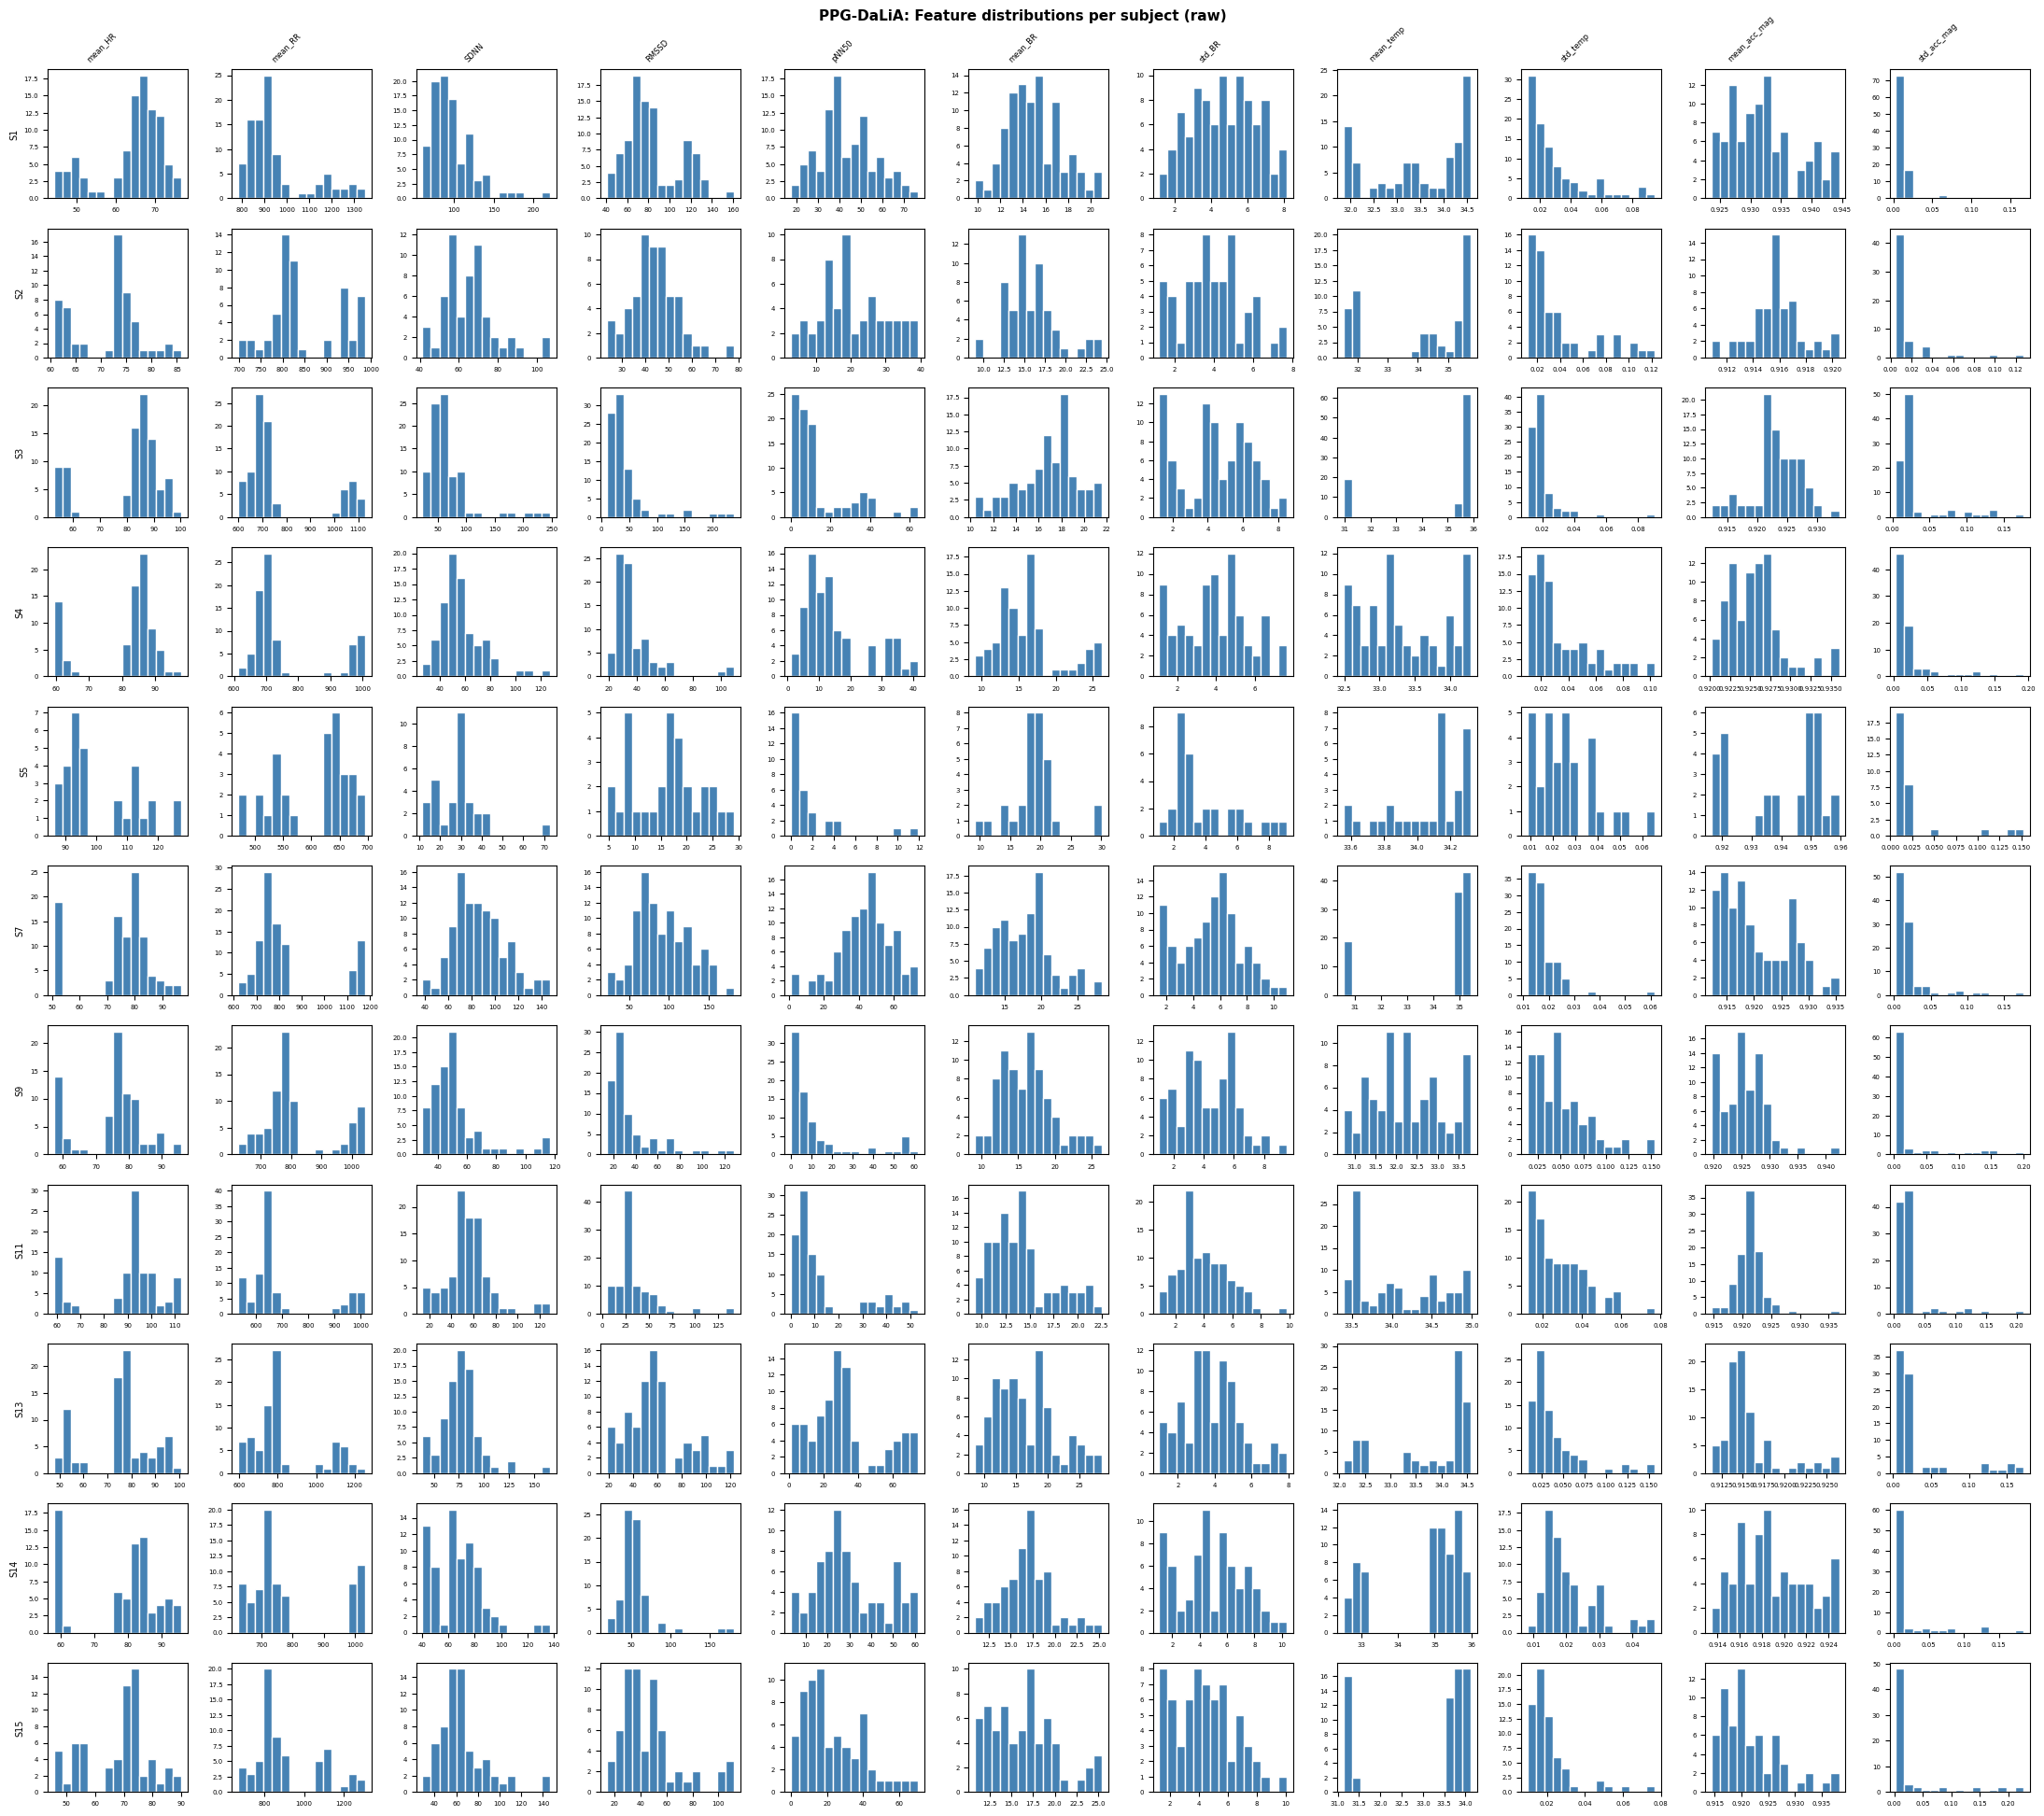

Distribution plot saved ✓


In [13]:
# Summary plot — one panel per subject

n_subjects = len(summary)
fig, axes  = plt.subplots(n_subjects, N_FEATS,
                           figsize=(N_FEATS * 2, n_subjects * 1.8))


plot_row = 0
for sid in SUBJECTS:
    if sid not in summary:
        continue
    X = np.load(f'{out_per_subject}/DALIA_{sid}_features_raw.npy')
    for col, fname in enumerate(FEATURE_NAMES):
        ax = axes[plot_row][col]
        ax.hist(X[:, col], bins=15, color='steelblue', edgecolor='white', lw=0.3)
        if plot_row == 0:
            ax.set_title(fname, fontsize=6, rotation=45, ha='right')
        if col == 0:
            ax.set_ylabel(sid, fontsize=7)
        ax.tick_params(labelsize=5)
    plot_row += 1

plt.suptitle('PPG-DaLiA: Feature distributions per subject (raw)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plot_path = f'{out_plots}/DALIA_feature_distributions.png'
plt.savefig(plot_path, dpi=120, bbox_inches='tight')
plt.show()
print(f"Distribution plot saved ✓")

In [17]:
# ── PDF Report ──

from reportlab.lib.pagesizes import A4
from reportlab.lib import colors
from reportlab.lib.units import cm
from reportlab.platypus import (SimpleDocTemplate, Paragraph, Spacer,
                                Table, TableStyle)
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle

pdf_path = f'{out_reports}/PPGDaLiA_preprocessing_report.pdf'
doc      = SimpleDocTemplate(pdf_path, pagesize=A4,
                             leftMargin=2*cm, rightMargin=2*cm,
                             topMargin=2*cm,  bottomMargin=2*cm)
styles  = getSampleStyleSheet()
h1      = ParagraphStyle('h1', fontSize=12, fontName='Helvetica-Bold',
                         spaceAfter=6, textColor=colors.HexColor('#16213e'))
normal  = ParagraphStyle('normal', fontSize=8, fontName='Helvetica',
                         spaceAfter=2, leading=11)
small   = ParagraphStyle('small',  fontSize=7, fontName='Helvetica',
                         spaceAfter=2, leading=10, wordWrap='CJK')

# Helper — wraps any string in a Paragraph so it word-wraps inside table cells
def P(txt, style=None):
    return Paragraph(str(txt), style or small)

story = []

# ── Title ─────────────────────────────────────────────────
story.append(Paragraph('PPG-DaLiA Preprocessing Report', h1))
story.append(Paragraph('R26-DS-012 | Component 1 | Sendanayake H.D.', normal))
story.append(Spacer(1, 10))

# ── 1. Dataset Overview ────────────────────────────────────
story.append(Paragraph('1. Dataset Overview', h1))
story.append(Paragraph(
    'PPG-DaLiA (Reiss et al., 2019) is a field study dataset collected for '
    'PPG-based heart rate estimation research. 15 subjects wore a chest-mounted '
    'RespiBAN device (ECG, Resp, ACC at 700 Hz) and a wrist Empatica E4 device '
    '(BVP 64 Hz, TEMP 4 Hz, ACC 32 Hz) across 8 naturalistic daily activities '
    'over approximately 2.5 hours per subject. This dataset is used in our pipeline '
    'exclusively for self-supervised baseline training — no stress labels exist.',
    normal))
story.append(Spacer(1, 8))

# ── 2. Subject Inclusion / Exclusion ──────────────────────
story.append(Paragraph('2. Subject Inclusion / Exclusion', h1))
story.append(Paragraph(
    'Subjects aged 35 and above were excluded to match the target population '
    '(young adults 18–35). S1 (age 34) was retained as physiologically '
    'equivalent to the 18–30 range for SSL baseline training purposes.',
    normal))
story.append(Spacer(1, 4))

subj_header = [P('Subject'), P('Age'), P('Gender'), P('Decision'), P('Reason')]
subj_info = [
    ('S1',  34, 'm', 'Keep',    'Age 34 — within acceptable range for SSL training'),
    ('S2',  28, 'm', 'Keep',    ''),
    ('S3',  25, 'm', 'Keep',    ''),
    ('S4',  25, 'm', 'Keep',    ''),
    ('S5',  21, 'f', 'Keep',    ''),
    ('S6',  37, 'f', 'Exclude', 'Age 37 (>35 threshold) AND hardware failure — data truncated to 87 min'),
    ('S7',  21, 'f', 'Keep',    ''),
    ('S8',  43, 'm', 'Exclude', 'Age 43 (>35 threshold)'),
    ('S9',  28, 'f', 'Keep',    ''),
    ('S10', 55, 'f', 'Exclude', 'Age 55 (>35 threshold)'),
    ('S11', 24, 'f', 'Keep',    ''),
    ('S12', 43, 'm', 'Exclude', 'Age 43 (>35 threshold)'),
    ('S13', 21, 'f', 'Keep',    ''),
    ('S14', 26, 'f', 'Keep',    ''),
    ('S15', 28, 'm', 'Keep',    ''),
]
subj_data = [subj_header]
for s, age, gen, dec, reason in subj_info:
    subj_data.append([P(s), P(str(age)), P(gen), P(dec), P(reason)])

t1 = Table(subj_data, colWidths=[1.5*cm, 1.0*cm, 1.3*cm, 2.0*cm, 10.2*cm])
t1.setStyle(TableStyle([
    ('BACKGROUND',    (0,0), (-1,0),  colors.HexColor('#16213e')),
    ('TEXTCOLOR',     (0,0), (-1,0),  colors.white),
    ('FONTNAME',      (0,0), (-1,0),  'Helvetica-Bold'),
    ('ROWBACKGROUNDS',(0,1), (-1,-1), [colors.white, colors.HexColor('#f0f4f8')]),
    ('GRID',          (0,0), (-1,-1), 0.4, colors.HexColor('#cccccc')),
    ('LEFTPADDING',   (0,0), (-1,-1), 4),
    ('RIGHTPADDING',  (0,0), (-1,-1), 4),
    ('TOPPADDING',    (0,0), (-1,-1), 4),
    ('BOTTOMPADDING', (0,0), (-1,-1), 4),
    ('VALIGN',        (0,0), (-1,-1), 'TOP'),
]))
story.append(t1)
story.append(Spacer(1, 8))

# ── 3. Baseline Activity Selection ────────────────────────
story.append(Paragraph('3. Baseline Activity Selection', h1))
story.append(Paragraph(
    'Baseline activities were selected based on two criteria: (1) low physical intensity so HRV is not suppressed by exercise, and (2) low motion so the ACC features reflect resting movement variation. Activity 1 (Sitting) was explicitly designated as the motion-artefact-free baseline by the original study authors. Activity 6 (Lunch) is a low-motion, low-cognitive-load sedentary state. Activities 5 (Driving) and 8 (Working at desk) were excluded: city driving is the stress condition in the AffectiveROAD dataset used in this same pipeline, and knowledge work at a desk is the documented stress condition in the SWELL-KW literature. Including either as baseline would create a direct scientific contradiction within the same pipeline.',
    normal))
story.append(Spacer(1, 4))

act_header = [P('ID'), P('Activity'), P('Duration'), P('Included'), P('Reason')]
act_rows = [
    ('1', 'Sitting',        '~10 min', 'YES',
     'Explicitly designated as motion-artefact-free baseline by original study authors. Zero motion.'),
    ('2', 'Stairs',         '~5 min',  'NO',
     'High intensity. HRV heavily suppressed.'),
    ('3', 'Table soccer',   '~5 min',  'NO',
     'Moderate intensity + competitive arousal.'),
    ('4', 'Cycling',        '~8 min',  'NO',
     'High intensity. HRV heavily suppressed.'),
    ('5', 'Driving',        '~15 min', 'NO',
     'City driving is the stress condition in AffectiveROAD dataset used in this same pipeline. '
     'Route included small city streets. Cannot verify absence of stress response. '
     'Scientifically inconsistent to label as baseline.'),
    ('6', 'Lunch break',    '~30 min', 'YES',
     'Low motion. Eating and talking.'),
    ('7', 'Walking',        '~10 min', 'NO',
     'Moderate intensity. HRV partially suppressed.'),
    ('8', 'Working at desk','~20 min', 'NO',
     'Desk knowledge work = stress condition in SWELL-KW literature. '
     'Unknown cognitive load. Cannot verify absence of cognitive stress. '
     'Scientifically inconsistent to label as baseline.'),
]
act_data = [act_header]
for row in act_rows:
    act_data.append([P(row[0]), P(row[1]), P(row[2]), P(row[3]), P(row[4])])

t2 = Table(act_data, colWidths=[0.7*cm, 2.5*cm, 1.8*cm, 1.5*cm, 10.0*cm])
t2.setStyle(TableStyle([
    ('BACKGROUND',    (0,0), (-1,0),  colors.HexColor('#16213e')),
    ('TEXTCOLOR',     (0,0), (-1,0),  colors.white),
    ('FONTNAME',      (0,0), (-1,0),  'Helvetica-Bold'),
    ('ROWBACKGROUNDS',(0,1), (-1,-1), [colors.white, colors.HexColor('#f0f4f8')]),
    ('GRID',          (0,0), (-1,-1), 0.4, colors.HexColor('#cccccc')),
    ('LEFTPADDING',   (0,0), (-1,-1), 4),
    ('RIGHTPADDING',  (0,0), (-1,-1), 4),
    ('TOPPADDING',    (0,0), (-1,-1), 4),
    ('BOTTOMPADDING', (0,0), (-1,-1), 4),
    ('VALIGN',        (0,0), (-1,-1), 'TOP'),
]))
story.append(t2)
story.append(Spacer(1, 8))

# ── 4. Signal Inspection Findings ─────────────────────────
story.append(Paragraph('4. Signal Inspection Findings (S1)', h1))
story.append(Paragraph(
    'ECG: Clean, active signal. Range -1.50 to +1.50 — ADC saturation at the hardware '
    'limit of the RespiBAN device (same clipping observed in WESAD, same device). '
    'R-peaks are sharp and clearly detectable. Not a problem for NeuroKit2 peak detection. '
    'Resp: Clean sinusoidal waveform. std during Sitting (3.00) and Lunch (3.64) — '
    'both consistent with resting respiratory patterns. '
    'Chest Temp: Confirmed dummy (-273.15 deg C = absolute zero placeholder). Never used. '
    'Wrist TEMP: Range 29.09 to 34.61 deg C, 100% valid (25–40 deg C range), '
    'no startup artifact detected. '
    'Zero NaNs across all signals. All activity segments are single contiguous blocks.',
    normal))
story.append(Spacer(1, 8))

# ── 5. Per-Subject Window Counts ──────────────────────────
story.append(Paragraph('5. Per-Subject Window Counts', h1))
story.append(Paragraph(
    'S5 Act6 note: 62 of 74 windows rejected due to chewing artifacts corrupting the '
    'chest Resp signal during active eating (computed BR 60–85 br/min, physiologically '
    'impossible). Final 12 windows (post-meal resting phase) were clean and retained. '
    'This is expected behavior — the inductive chest strap cannot distinguish chewing '
    'motion from thoracic breathing. The BR validity filter handled this correctly.',
    normal))
story.append(Spacer(1, 4))

win_header = [P('Subject'), P('Windows Kept'), P('Log Entries')]
win_data   = [win_header]
total_w = 0
for sid in SUBJECTS:
    if sid in summary:
        nw = summary[sid]['n_windows']
        nl = len(summary[sid]['log'])
        total_w += nw
        win_data.append([P(sid), P(str(nw)), P(str(nl))])
    else:
        win_data.append([P(sid), P('0'), P('No windows produced')])
win_data.append([P('TOTAL'), P(str(total_w)), P('')])

t3 = Table(win_data, colWidths=[2.8*cm, 3.8*cm, 9.8*cm])
t3.setStyle(TableStyle([
    ('BACKGROUND',    (0,0),  (-1,0),  colors.HexColor('#16213e')),
    ('TEXTCOLOR',     (0,0),  (-1,0),  colors.white),
    ('FONTNAME',      (0,0),  (-1,0),  'Helvetica-Bold'),
    ('ROWBACKGROUNDS',(0,1),  (-1,-2), [colors.white, colors.HexColor('#f0f4f8')]),
    ('BACKGROUND',    (0,-1), (-1,-1), colors.HexColor('#16213e')),
    ('TEXTCOLOR',     (0,-1), (-1,-1), colors.white),
    ('FONTNAME',      (0,-1), (-1,-1), 'Helvetica-Bold'),
    ('GRID',          (0,0),  (-1,-1), 0.4, colors.HexColor('#cccccc')),
    ('LEFTPADDING',   (0,0),  (-1,-1), 4),
    ('RIGHTPADDING',  (0,0),  (-1,-1), 4),
    ('TOPPADDING',    (0,0),  (-1,-1), 4),
    ('BOTTOMPADDING', (0,0),  (-1,-1), 4),
    ('VALIGN',        (0,0),  (-1,-1), 'TOP'),
]))
story.append(t3)
story.append(Spacer(1, 8))

# ── 6. Features ───────────────────────────────────────────
story.append(Paragraph('6. Features (11 per window)', h1))
units = {
    'mean_HR':'bpm', 'mean_RR':'ms', 'SDNN':'ms', 'RMSSD':'ms',
    'pNN50':'%', 'mean_BR':'br/min', 'std_BR':'br/min',
    'mean_temp':'°C', 'std_temp':'°C',
    'mean_acc_mag':'g', 'std_acc_mag':'g'
}
sources = {
    'mean_HR':'Chest ECG (700 Hz)', 'mean_RR':'Chest ECG (700 Hz)',
    'SDNN':'Chest ECG (700 Hz)',    'RMSSD':'Chest ECG (700 Hz)',
    'pNN50':'Chest ECG (700 Hz)',   'mean_BR':'Chest Resp (700 Hz)',
    'std_BR':'Chest Resp (700 Hz)', 'mean_temp':'Wrist TEMP (4 Hz)',
    'std_temp':'Wrist TEMP (4 Hz)', 'mean_acc_mag':'Chest ACC (700 Hz)',
    'std_acc_mag':'Chest ACC (700 Hz)'
}
feat_header = [P('#'), P('Feature'), P('Source'), P('Unit')]
feat_data   = [feat_header]
for i, fn in enumerate(FEATURE_NAMES):
    feat_data.append([P(str(i)), P(fn), P(sources[fn]), P(units[fn])])

t4 = Table(feat_data, colWidths=[0.7*cm, 3.1*cm, 7.4*cm, 1.2*cm])
t4.setStyle(TableStyle([
    ('BACKGROUND',    (0,0), (-1,0),  colors.HexColor('#16213e')),
    ('TEXTCOLOR',     (0,0), (-1,0),  colors.white),
    ('FONTNAME',      (0,0), (-1,0),  'Helvetica-Bold'),
    ('ROWBACKGROUNDS',(0,1), (-1,-1), [colors.white, colors.HexColor('#f0f4f8')]),
    ('GRID',          (0,0), (-1,-1), 0.4, colors.HexColor('#cccccc')),
    ('LEFTPADDING',   (0,0), (-1,-1), 4),
    ('RIGHTPADDING',  (0,0), (-1,-1), 4),
    ('TOPPADDING',    (0,0), (-1,-1), 4),
    ('BOTTOMPADDING', (0,0), (-1,-1), 4),
    ('VALIGN',        (0,0), (-1,-1), 'TOP'),
]))
story.append(t4)
story.append(Spacer(1, 8))

# ── 7. Normalisation ──────────────────────────────────────
story.append(Paragraph('7. Normalisation', h1))
story.append(Paragraph(
    'Per-subject Z-score normalisation. Mean and std are computed exclusively from '
    'all baseline windows for that subject (all windows in this dataset are baseline). '
    'The same statistics are applied to produce the normalised arrays. '
    'Raw (un-normalised) arrays are also saved for reference. '
    'This matches the personalised SSL approach where each subject serves as '
    'their own physiological reference — population-level normalisation is not used.',
    normal))
story.append(Spacer(1, 8))

# ── 8. Quality Log ────────────────────────────────────────
story.append(Paragraph('8. Quality Log', h1))
all_notes = []
for sid in SUBJECTS:
    if sid in quality_log:
        for note in quality_log[sid]:
            all_notes.append(f'{sid}: {note}')
if all_notes:
    for note in all_notes:
        story.append(Paragraph(f'• {note}', normal))
else:
    story.append(Paragraph('No rejections or issues found.', normal))
story.append(Spacer(1, 8))

# ── 9. Saved Files ────────────────────────────────────────
story.append(Paragraph('9. Saved Files', h1))
files_rows = [
    ('per_subject/DALIA_SN_features_raw.npy',  'Raw feature array per subject (n_windows × 11)'),
    ('per_subject/DALIA_SN_features_norm.npy', 'Z-score normalised features per subject'),
    ('per_subject/DALIA_SN_labels.npy',        'Labels — all 0 (baseline). No stress labels in this dataset.'),
    ('per_subject/DALIA_SN_norm_mean.npy',     'Normalisation mean vector (computed from baseline windows)'),
    ('per_subject/DALIA_SN_norm_std.npy',      'Normalisation std vector (computed from baseline windows)'),
    ('combined/DALIA_X_all_raw.npy',           'All subjects combined — raw features (846 × 11)'),
    ('combined/DALIA_y_all.npy',               'All subjects combined — labels (all 0)'),
    ('combined/DALIA_subject_ids.npy',         'Subject ID string per window — used for LOSO splits'),
    ('PPGDaLiA_feature_names.json',            'Feature metadata, activity decisions, pipeline notes'),
]
files_header = [P('File'), P('Description')]
files_data   = [files_header] + [[P(f), P(desc)] for f, desc in files_rows]

tf = Table(files_data, colWidths=[6.3*cm, 9.7*cm])
tf.setStyle(TableStyle([
    ('BACKGROUND',    (0,0), (-1,0),  colors.HexColor('#16213e')),
    ('TEXTCOLOR',     (0,0), (-1,0),  colors.white),
    ('FONTNAME',      (0,0), (-1,0),  'Helvetica-Bold'),
    ('ROWBACKGROUNDS',(0,1), (-1,-1), [colors.white, colors.HexColor('#f0f4f8')]),
    ('GRID',          (0,0), (-1,-1), 0.4, colors.HexColor('#cccccc')),
    ('LEFTPADDING',   (0,0), (-1,-1), 4),
    ('RIGHTPADDING',  (0,0), (-1,-1), 4),
    ('TOPPADDING',    (0,0), (-1,-1), 4),
    ('BOTTOMPADDING', (0,0), (-1,-1), 4),
    ('VALIGN',        (0,0), (-1,-1), 'TOP'),
]))
story.append(tf)

# ── Build ─────────────────────────────────────────────────
doc.build(story)
print(f'PDF report saved → {pdf_path}')

PDF report saved → /content/drive/MyDrive/R26_DS_012_RESEARCH_HDS/Outputs/PPGDaLiA/reports/PPGDaLiA_preprocessing_report.pdf
